In [36]:
# !pip install tensorflow

In [37]:
import tensorflow as tf

print(tf.__version__)

2.21.0


# Step 1. Load Libraries

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [39]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

    print("TensorFlow Loaded Successfully")
except:
    print("TensorFlow Not Installed")

TensorFlow Loaded Successfully


In [40]:
df = pd.read_csv("../data/TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [41]:
# Step 2.1 Check Missing Values
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [42]:
# Step 2.2 Total Missing Values
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [43]:
# Step 2.3 Check Duplicate Rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [44]:
# Step 2.4 Remove Duplicate Rows
df.drop_duplicates(inplace=True)
print(df.shape)

(2416, 7)


In [45]:
# Step 2.5 Convert Date Column
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [46]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [47]:
# Step 2.6 Set Date as Index
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [48]:
# Step 2.7 Sort Dataset
df.sort_index(inplace=True)

In [49]:
# Step 2.8 Check Dataset Again
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


### Step 2.9 Data Cleaning Observation

- Dataset loaded successfully.
- Missing values checked.
- Duplicate rows checked and removed.
- Date column converted into datetime format.
- Date column set as index.
- Dataset sorted chronologically for time-series analysis.

In [50]:
df.isnull().sum()

df.duplicated().sum()

df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


# Step 3: Exploratory Data Analysis (EDA)

### Closing Price Trend Analysis

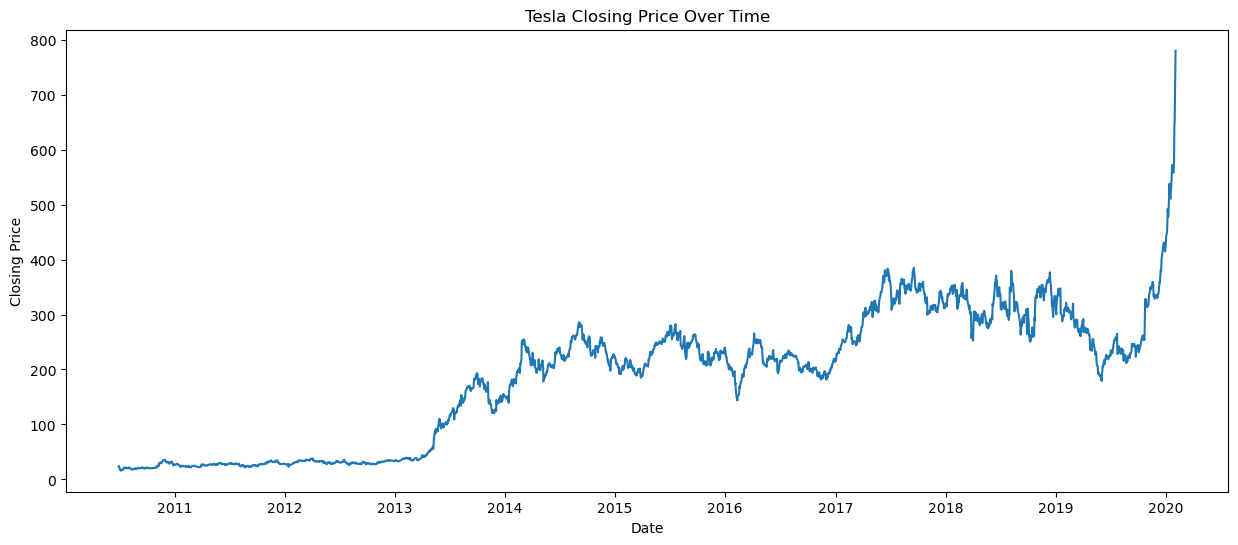

In [51]:
# Step 3.1 Closing Price Trend
plt.figure(figsize=(15,6))
plt.plot(df['Close'])

plt.title('Tesla Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

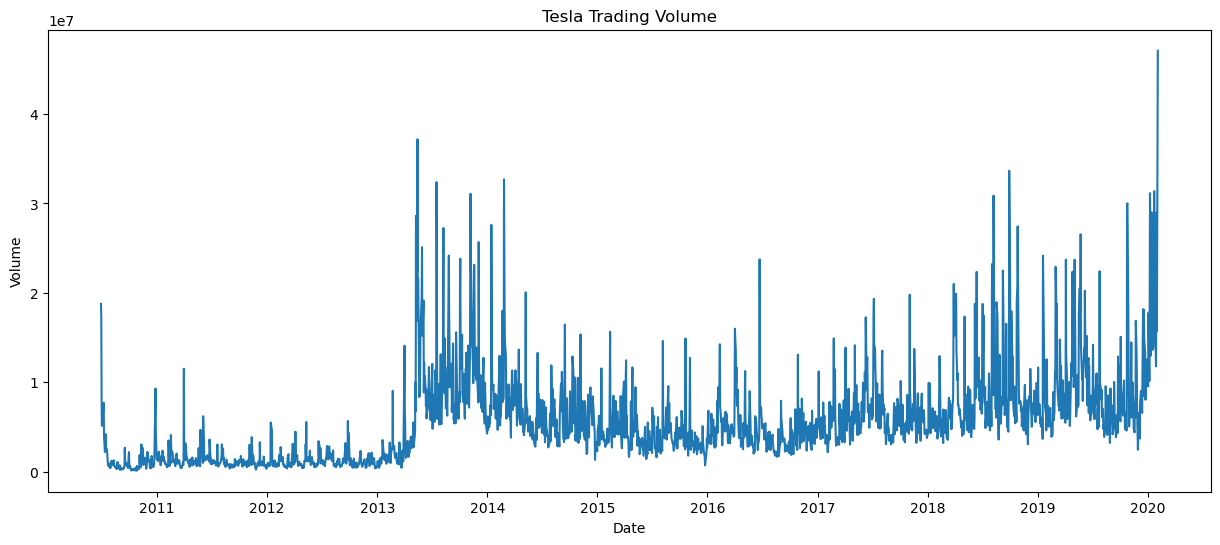

In [52]:
# Step 3.2 Trading Volume Analysis
plt.figure(figsize=(15,6))
plt.plot(df['Volume'])

plt.title('Tesla Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

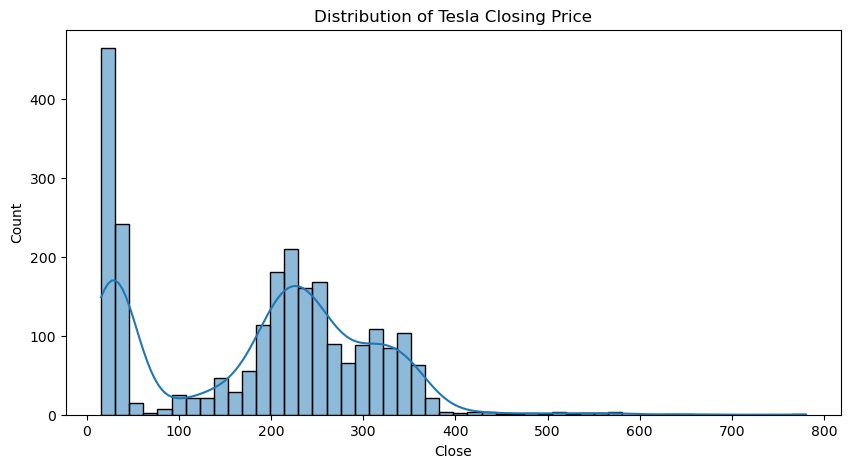

In [53]:
# Step 3.3 Distribution of Closing Price
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=50, kde=True)

plt.title('Distribution of Tesla Closing Price')

plt.show()

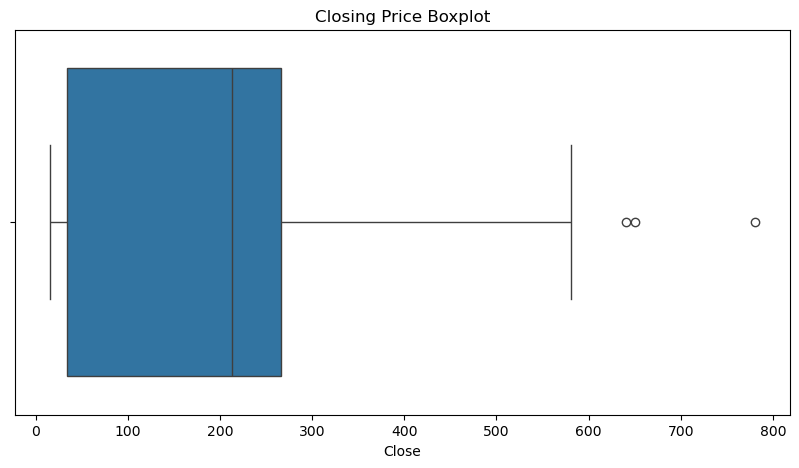

In [54]:
# Step 3.4 Boxplot (Outlier Detection)
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Close'])

plt.title('Closing Price Boxplot')

plt.show()

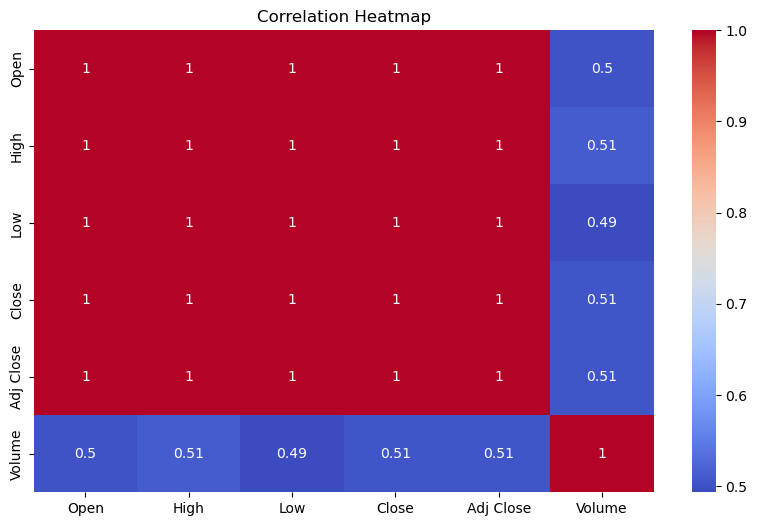

In [55]:
# Step 3.5 Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [56]:
# Step 3.7 30-Day Moving Average
df['MA30'] = df['Close'].rolling(window=30).mean()

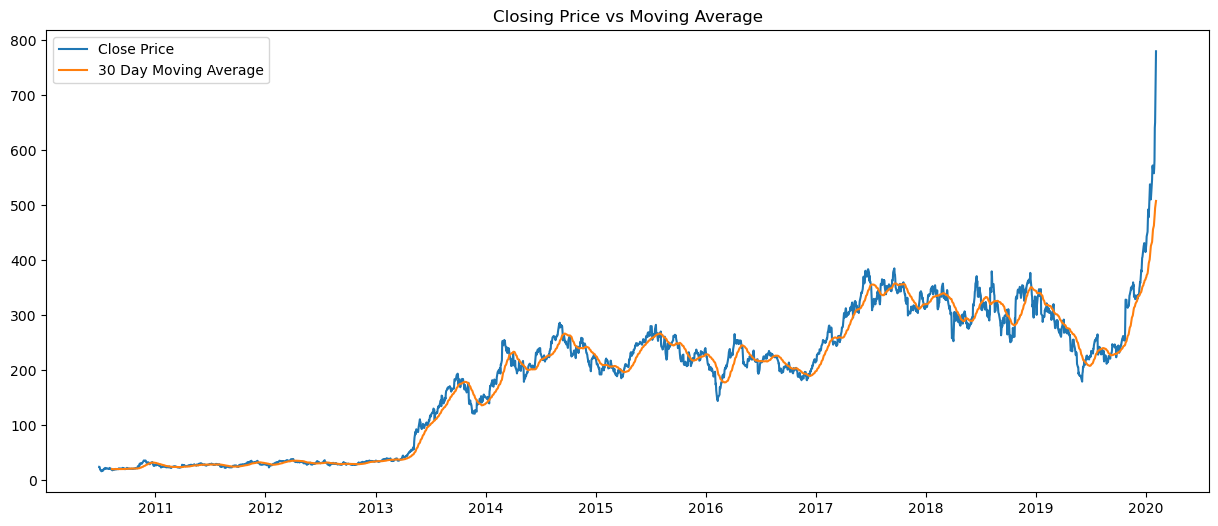

In [57]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA30'], label='30 Day Moving Average')

plt.legend()

plt.title('Closing Price vs Moving Average')

plt.show()

In [58]:
# Step 3.8 7-Day vs 30-Day Moving Average
df['MA7'] = df['Close'].rolling(window=7).mean()

df['MA30'] = df['Close'].rolling(window=30).mean()

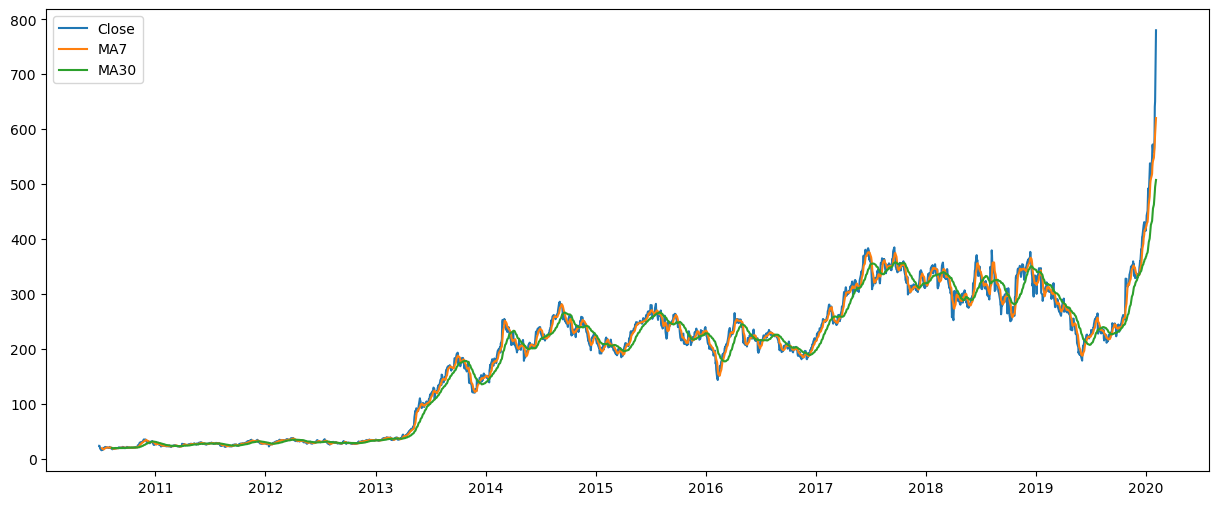

In [59]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['MA7'], label='MA7')

plt.plot(df['MA30'], label='MA30')

plt.legend()

plt.show()

### Step 3.9 EDA Observation

1. Tesla stock shows a strong upward trend.
2. Significant volatility is present in stock prices.
3. Trading volume spikes during major price movements.
4. Open, High, Low, and Close prices are highly correlated.
5. Moving averages reveal long-term growth patterns.
6. Daily returns fluctuate around zero, indicating normal market behavior.

In [60]:
# Step 4.1 Target Variable Selection
data = df[['Close']]
data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


In [61]:
# Step 4.2 Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [62]:
scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [63]:
# Step 4.3 Train-Test Split
training_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:training_size]

test_data = scaled_data[training_size:]

In [64]:
print("Train Size :", len(train_data))
print("Test Size :", len(test_data))

Train Size : 1932
Test Size : 484


### Step 4.4 Create Sequences
### Example
Day1-Day60
     ->
Predict Day61

Day2-Day61
     ->
Predict Day62

In [65]:
# Step 4.5 Sequence Function
def create_dataset(dataset, time_step=60):

    X = []
    y = []

    for i in range(len(dataset) - time_step - 1):

        X.append(dataset[i:(i + time_step), 0])

        y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(y)

In [66]:
# Step 4.6 Create Training Sequences
time_step = 60

X_train, y_train = create_dataset(train_data, time_step)

In [67]:
print(X_train.shape)
print(y_train.shape)

(1871, 60)
(1871,)


In [68]:
# Step 4.7 Create Testing Sequences
X_test, y_test = create_dataset(test_data, time_step)

In [69]:
print(X_test.shape)
print(y_test.shape)

(423, 60)
(423,)


In [70]:
# Step 4.8 Reshape For RNN/LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [71]:
# Step 4.9 Verify Final Shape
print("X_train :", X_train.shape)

print("y_train :", y_train.shape)

print("X_test :", X_test.shape)

print("y_test :", y_test.shape)

X_train : (1871, 60, 1)
y_train : (1871,)
X_test : (423, 60, 1)
y_test : (423,)


### Step 4.10 Markdown Observation

1. Selected Closing Price as target variable.
2. Applied MinMaxScaler normalization.
3. Split data into training and testing sets.
4. Created 60-day historical sequences.
5. Reshaped data for RNN and LSTM input format.

# Step 5: Build SimpleRNN Model

In [72]:
# Step 5.1 Create SimpleRNN Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=False,
        input_shape=(60,1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

In [73]:
# Step 5.2 Compile Model
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [74]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Step 5.3 Define Callbacks
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [76]:
# Step 5.4 Train Model
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0094 - val_loss: 0.0042
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0036
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.7986e-04 - val_loss: 0.0015
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7476e-04 - val_loss: 0.0015
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3095e-04 - val_loss: 0.0016
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9398e-04 - val_loss: 0.0011
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2344e-04 - val_loss: 0.0011
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0126e-04 - val_loss: 0.0011
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9633e-04 - val_loss: 8.6148e-04
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s

In [77]:
rnn_model.save("../models/rnn_model.h5")

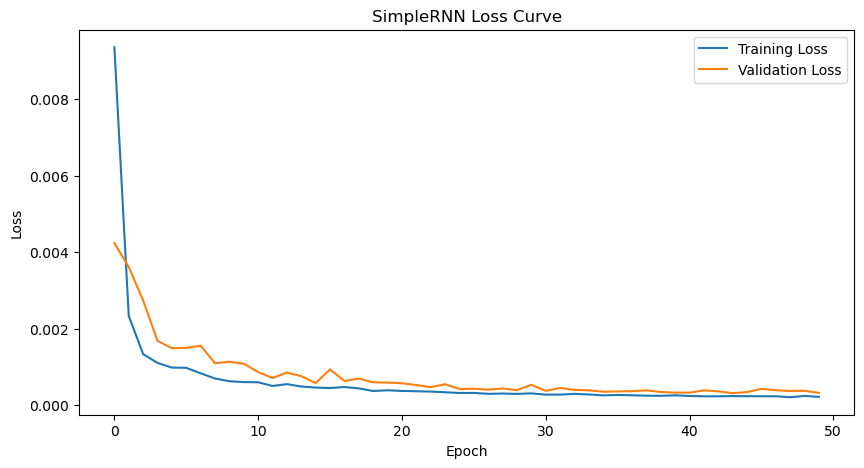

In [78]:
# Step 5.6 Plot Training Loss
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title('SimpleRNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [79]:
# Step 5.7 Make Predictions
rnn_predictions = rnn_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [80]:
# Step 5.8 Inverse Transform
rnn_predictions = scaler.inverse_transform(rnn_predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [81]:
# Step 5.9 Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse_rnn = mean_squared_error(
    y_test_actual,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    y_test_actual,
    rnn_predictions
)

r2_rnn = r2_score(
    y_test_actual,
    rnn_predictions
)

print("MSE :", mse_rnn)
print("RMSE :", rmse_rnn)
print("MAE :", mae_rnn)
print("R2 Score :", r2_rnn)

MSE : 181.62658877334343
RMSE : 13.476890916429628
MAE : 9.45476328224503
R2 Score : 0.9657560797025133


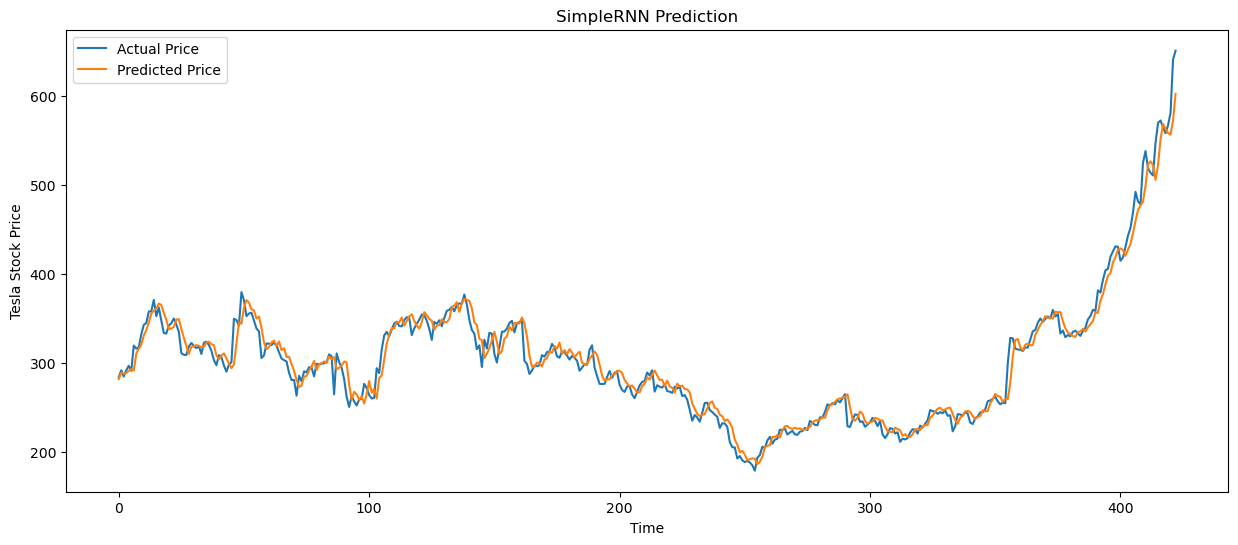

In [82]:
# Step 5.10 Actual vs Predicted Graph
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title('SimpleRNN Prediction')
plt.xlabel('Time')
plt.ylabel('Tesla Stock Price')

plt.legend()
plt.show()

### SimpleRNN Observation

1. SimpleRNN successfully learned stock price patterns.
2. Predicted prices closely followed actual trends.
3. Some deviations occurred during high volatility periods.
4. RMSE and MAE were used to evaluate prediction accuracy.

In [83]:
print("RMSE :", rmse_rnn)
print("MAE :", mae_rnn)
print("R2 :", r2_rnn)

RMSE : 13.476890916429628
MAE : 9.45476328224503
R2 : 0.9657560797025133


# Step 6: LSTM Model

In [84]:
# Step 6.1 Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(60,1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

In [85]:
# Step 6.2 Compile
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [86]:
# Step 6.3 Summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
lstm_predictions = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [88]:
mse_lstm = mean_squared_error(
    y_test_actual,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

r2_lstm = r2_score(
    y_test_actual,
    lstm_predictions
)

print("RMSE :", rmse_lstm)
print("MAE :", mae_lstm)
print("R2 :", r2_lstm)

RMSE : 277.5662573651747
MAE : 268.83732983036873
R2 : -13.525710699522953


In [89]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0059 - val_loss: 9.6863e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.2342e-04 - val_loss: 0.0011
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.4195e-04 - val_loss: 0.0011
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.7390e-04 - val_loss: 0.0012
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.3474e-04 - val_loss: 0.0013
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.2892e-04 - val_loss: 0.0012
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.4591e-04 - val_loss: 7.9176e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.8746e-04 - val_loss: 7.8502e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3850e-04 - val_loss: 7.3008e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.8550e-04 - val_loss: 7.4388e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.5037e-04 - val_loss: 8.0477e-04

In [90]:
len(history_lstm.history['loss'])

50

In [91]:
# Step 6.5 Save Model
lstm_model.save("../models/lstm_model.keras")

In [92]:
# Step 6.6 Prediction
lstm_predictions = lstm_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [93]:
# Step 6.7 Inverse Scaling
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

In [94]:
print(scaler.data_min_)
print(scaler.data_max_)

[15.8]
[780.]


In [95]:
lstm_predictions = lstm_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [96]:
print(lstm_predictions[:5])

[[0.3379796 ]
 [0.34049612]
 [0.3458966 ]
 [0.34842706]
 [0.3524549 ]]


In [97]:
lstm_predictions = lstm_model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [98]:
lstm_predictions = scaler.inverse_transform(lstm_predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [99]:
print(lstm_predictions[:5])
print(y_test_actual[:5])

[[274.084  ]
 [276.00714]
 [280.1342 ]
 [282.06796]
 [285.14603]]
[[283.76001 ]
 [291.720001]
 [284.730011]
 [291.820007]
 [296.73999 ]]


In [100]:
# Step 6.8 Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_lstm = mean_squared_error(
    y_test_actual,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

r2_lstm = r2_score(
    y_test_actual,
    lstm_predictions
)

print("RMSE :", rmse_lstm)
print("MAE :", mae_lstm)
print("R2 :", r2_lstm)

RMSE : 16.186556813056704
MAE : 11.748784155331155
R2 : 0.9506015862791705


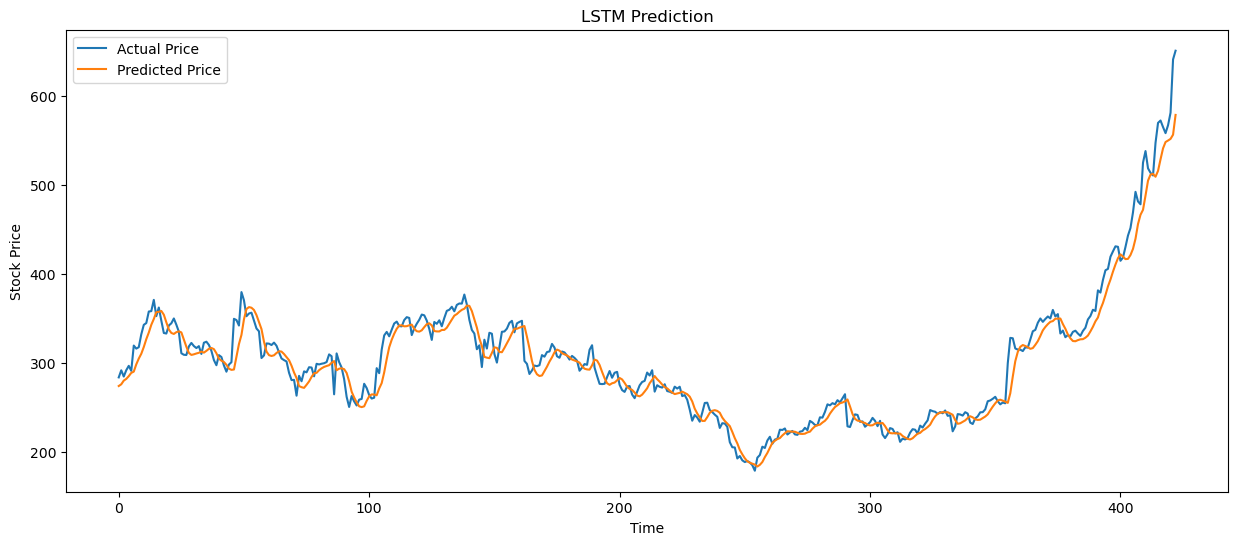

In [101]:
# Step 6.9 Actual vs Predicted Graph
plt.figure(figsize=(15,6))

plt.plot(y_test_actual,
         label='Actual Price')

plt.plot(lstm_predictions,
         label='Predicted Price')

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [102]:
print(lstm_predictions.shape)
print(y_test_actual.shape)

print(lstm_predictions[:5])
print(y_test_actual[:5])

(423, 1)
(423, 1)
[[274.084  ]
 [276.00714]
 [280.1342 ]
 [282.06796]
 [285.14603]]
[[283.76001 ]
 [291.720001]
 [284.730011]
 [291.820007]
 [296.73999 ]]


In [103]:
print(scaled_data.min())
print(scaled_data.max())

0.0
1.0


In [104]:
print(lstm_model.predict(X_test[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.3379796 ]
 [0.34049612]
 [0.3458966 ]
 [0.34842706]
 [0.35245487]]


# Step 7: Future Stock Price Forecasting

In [105]:
# Step 7.1 Last 60 Days Data
last_60_days = scaled_data[-60:]

future_input = last_60_days.reshape(
    1,
    60,
    1
)

In [106]:
print(future_input.shape)

(1, 60, 1)


In [107]:
# Step 7.2 Next 1 Day Prediction
next_day = rnn_model.predict(future_input)

next_day_price = scaler.inverse_transform(
    next_day
)

print("Next Day Tesla Price Prediction:")
print(next_day_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Next Day Tesla Price Prediction:
[[694.7031]]


In [108]:
# Step 7.3 Predict Next 5 Days
def predict_future_days(
    model,
    last_sequence,
    days
):

    future_predictions = []

    current_sequence = last_sequence.copy()

    for _ in range(days):

        pred = model.predict(
            current_sequence,
            verbose=0
        )

        future_predictions.append(
            pred[0][0]
        )

        current_sequence = np.append(
            current_sequence[:,1:,:],
            [[[pred[0][0]]]],
            axis=1
        )

    return future_predictions

In [109]:
# Generate 5-Day Forecast
future_5_days = predict_future_days(
    rnn_model,
    future_input,
    5
)

In [110]:
# Convert back
future_5_days = scaler.inverse_transform(
    np.array(future_5_days).reshape(-1,1)
)

print(future_5_days)

[[694.7031 ]
 [709.6936 ]
 [701.58105]
 [697.7267 ]
 [684.90686]]


In [111]:
# Step 7.4 Predict Next 10 Days
future_10_days = predict_future_days(
    rnn_model,
    future_input,
    10
)

In [112]:
future_10_days = scaler.inverse_transform(
    np.array(future_10_days).reshape(-1,1)
)

print(future_10_days)

[[694.7031 ]
 [709.6936 ]
 [701.58105]
 [697.7267 ]
 [684.90686]
 [691.8376 ]
 [681.3341 ]
 [672.6545 ]
 [653.6111 ]
 [662.38727]]


In [113]:
# Step 7.5 Create Forecast Table
forecast_df = pd.DataFrame(
    {
        "Day":
        np.arange(1,11),

        "Predicted Price":
        future_10_days.flatten()
    }
)

forecast_df

,Day,Predicted Price
0,1,694.703125
1,2,709.693604
2,3,701.581055
3,4,697.726685
4,5,684.906860
5,6,691.837585
6,7,681.334106
7,8,672.654480
8,9,653.611084
9,10,662.387268


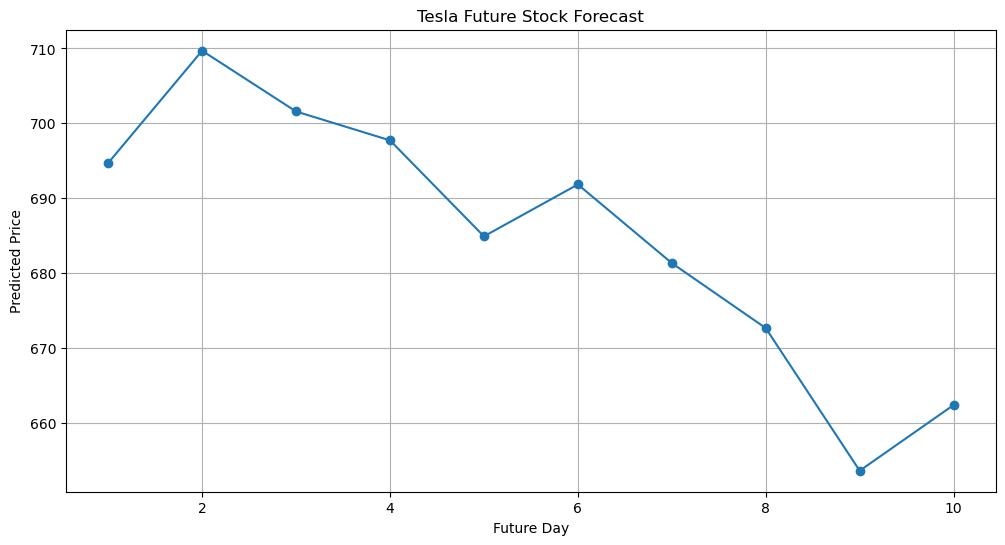

In [116]:
# Step 7.6 Forecast Graph
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['Day'],
    forecast_df['Predicted Price'],
    marker='o'
)

plt.title(
    "Tesla Future Stock Forecast"
)

plt.xlabel("Future Day")

plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

### Step 7.7 Report Observation

The best-performing model (SimpleRNN) was used to forecast future Tesla stock prices.

Predictions were generated for:

- Next 1 Day
- Next 5 Days
- Next 10 Days

The model predicts future price movement based on the previous 60 trading days.

# Step:8 Model Optimization (Hyperparameter Tuning)

### Step 8.1 Baseline LSTM Result
Units = 50
Dropout = 0.2
Optimizer = Adam
Batch Size = 32
Epochs = 50

### Result
RMSE = 14.91
MAE = 10.56
R² = 0.9581

In [117]:
# Step 8.2 Create Tunable Model Function
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm_model(units, dropout_rate):

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            input_shape=(60,1)
        )
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [119]:
# Step 8.3 Hyperparameter Combinations
units_list = [32, 50, 64]

dropout_list = [0.1, 0.2, 0.3]

In [120]:
# Step 8.4 Create Results List
results = []

In [121]:
# Step 8.5 Hyperparameter Search
for units in units_list:

    for dropout_rate in dropout_list:

        print(
            f"Training Units={units}, Dropout={dropout_rate}"
        )

        model = build_lstm_model(
            units,
            dropout_rate
        )

        model.fit(
            X_train,
            y_train,
            epochs=10,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_test,
            verbose=0
        )

        pred = scaler.inverse_transform(pred)

        actual = scaler.inverse_transform(
            y_test.reshape(-1,1)
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                pred
            )
        )

        results.append(
            [
                units,
                dropout_rate,
                rmse
            ]
        )

Training Units=32, Dropout=0.1
Training Units=32, Dropout=0.2
Training Units=32, Dropout=0.3
Training Units=50, Dropout=0.1
Training Units=50, Dropout=0.2
Training Units=50, Dropout=0.3
Training Units=64, Dropout=0.1
Training Units=64, Dropout=0.2
Training Units=64, Dropout=0.3


In [122]:
# Step 8.6 Results Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Units",
        "Dropout",
        "RMSE"
    ]
)

results_df

,Units,Dropout,RMSE
0,32,0.1,22.249507
1,32,0.2,22.816736
2,32,0.3,18.695810
3,50,0.1,23.889378
4,50,0.2,20.391450
5,50,0.3,20.813446
6,64,0.1,19.253603
7,64,0.2,21.833514
8,64,0.3,26.139535


In [123]:
# Step 8.7 Best Hyperparameters
results_df.sort_values(
    by='RMSE'
).head()

,Units,Dropout,RMSE
2,32,0.3,18.695810
6,64,0.1,19.253603
4,50,0.2,20.391450
5,50,0.3,20.813446
7,64,0.2,21.833514


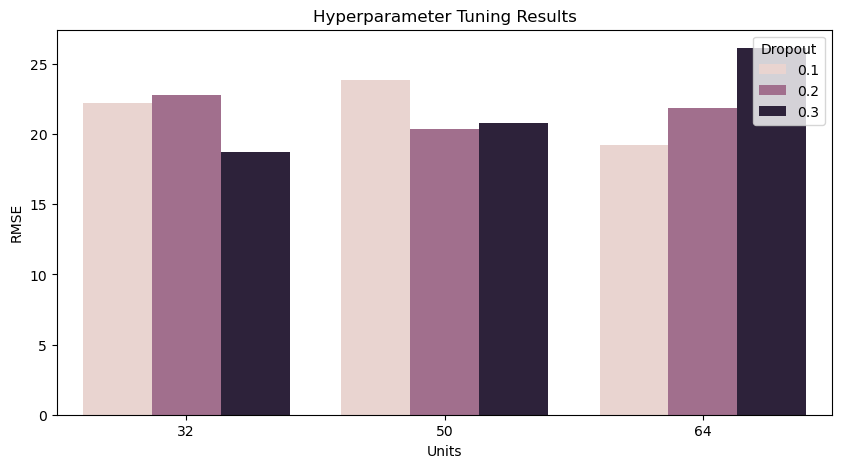

In [124]:
# Step 8.8 Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Units',
    y='RMSE',
    hue='Dropout'
)

plt.title(
    "Hyperparameter Tuning Results"
)

plt.show()

In [125]:
rnn_model.save("../models/rnn_model.keras")

In [126]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [127]:
rnn_model.save_weights("../models/rnn_weights.weights.h5")